<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


Compensation Statistics:
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

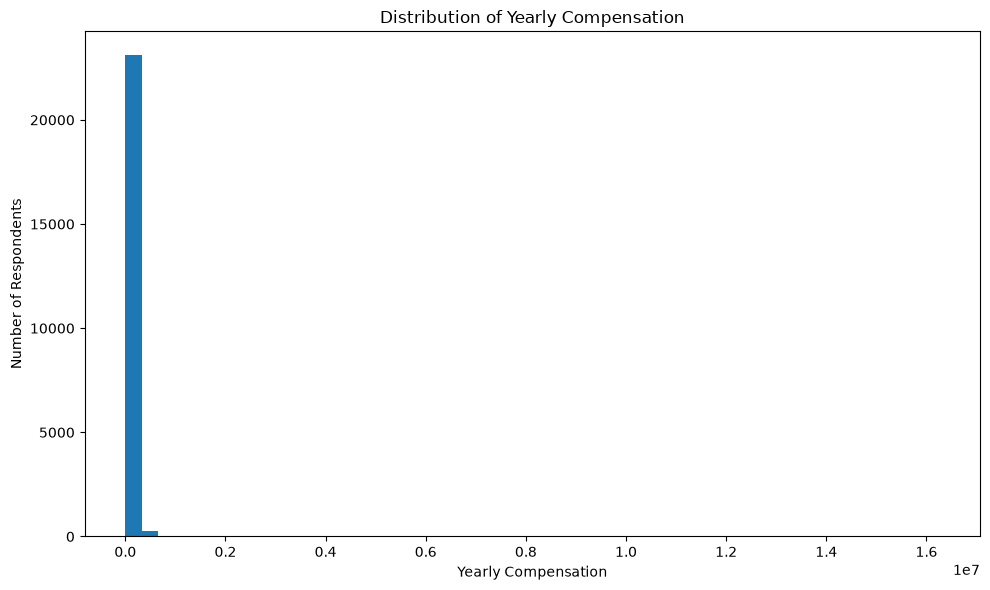

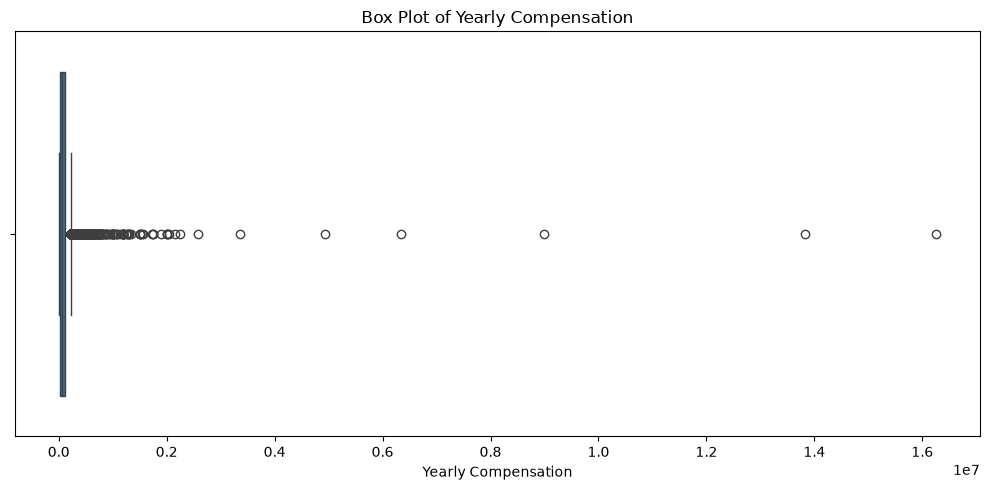

In [3]:
## Write your code here

# Remove missing compensation values
compensation = df["ConvertedCompYearly"].dropna()

# Display basic statistics
print("Compensation Statistics:")
print(compensation.describe())

# Histogram
plt.figure(figsize=(10, 6))

plt.hist(
    compensation,
    bins=50
)

plt.title("Distribution of Yearly Compensation")
plt.xlabel("Yearly Compensation")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

# Box plot
plt.figure(figsize=(10, 5))

sns.boxplot(
    x=compensation
)

plt.title("Box Plot of Yearly Compensation")
plt.xlabel("Yearly Compensation")
plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
## Write your code here

# Filter full-time employees
full_time = df[
    df["Employment"] == "Employed, full-time"
]

# Remove missing compensation values
full_time_compensation = full_time[
    "ConvertedCompYearly"
].dropna()

# Calculate median compensation
median_full_time = full_time_compensation.median()

print("Number of full-time employees:",
      len(full_time))

print("Median compensation for full-time employees:",
      median_full_time)

Number of full-time employees: 39041
Median compensation for full-time employees: 69814.0

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



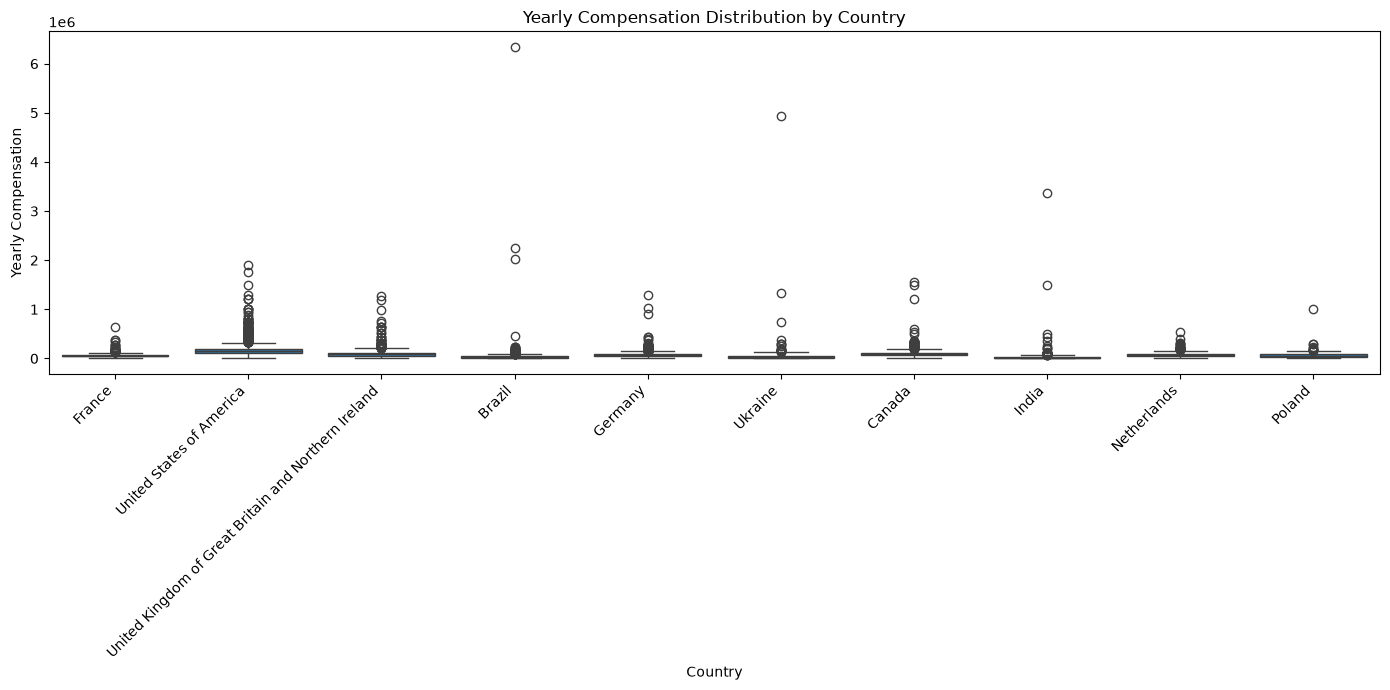

In [5]:
## Write your code here

# Find the 10 countries with the most respondents
top_countries = (
    df["Country"]
    .value_counts()
    .head(10)
    .index
)

# Filter the dataset
country_compensation = df[
    df["Country"].isin(top_countries)
][
    ["Country", "ConvertedCompYearly"]
].dropna()

# Create box plot
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=country_compensation,
    x="Country",
    y="ConvertedCompYearly"
)

plt.title("Yearly Compensation Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Yearly Compensation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [6]:
## Write your code here

# Calculate Q1 and Q3
Q1 = df["ConvertedCompYearly"].quantile(0.25)
Q3 = df["ConvertedCompYearly"].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

# Create refined DataFrame
df_no_outliers = df[
    (df["ConvertedCompYearly"].isna()) |
    (
        (df["ConvertedCompYearly"] >= lower_bound) &
        (df["ConvertedCompYearly"] <= upper_bound)
    )
].copy()

print("\nOriginal dataset shape:", df.shape)
print("Dataset shape after removing outliers:",
      df_no_outliers.shape)

print("Number of rows removed:",
      len(df) - len(df_no_outliers))

Q1: 32712.0
Q3: 107971.5
IQR: 75259.5
Lower bound: -80177.25
Upper bound: 220860.75
Original dataset shape: (65437, 114)
Dataset shape after removing outliers: (64459, 114)
Number of rows removed: 978

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


Correlation Matrix:
                     ConvertedCompYearly   WorkExp  JobSatPoints_1
ConvertedCompYearly             1.000000  0.406993       -0.059643
WorkExp                         0.406993  1.000000       -0.032388
JobSatPoints_1                 -0.059643 -0.032388        1.000000

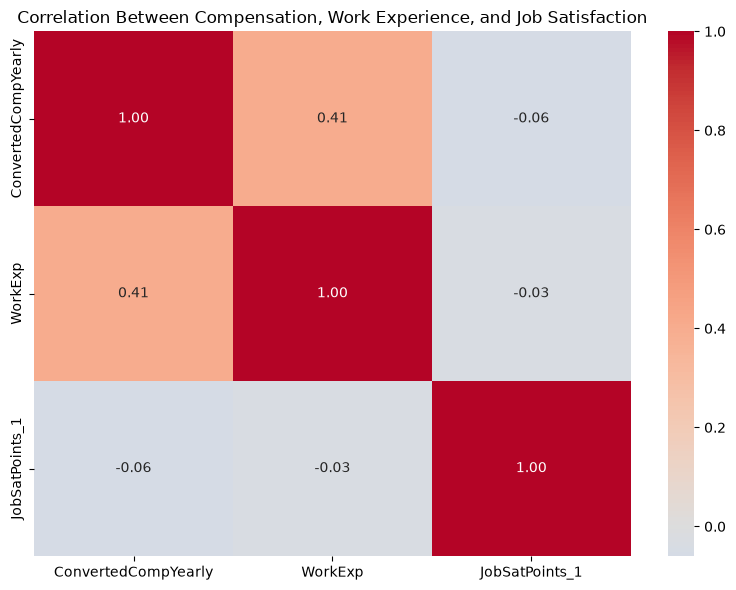

In [7]:
## Write your code here

# Make copies of the relevant columns
correlation_data = df_no_outliers[
    [
        "ConvertedCompYearly",
        "WorkExp",
        "JobSatPoints_1"
    ]
].copy()

# Convert columns to numeric
for column in correlation_data.columns:
    correlation_data[column] = pd.to_numeric(
        correlation_data[column],
        errors="coerce"
    )

# Remove rows with missing values
correlation_data = correlation_data.dropna()

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Compensation, Work Experience, and Job Satisfaction")
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


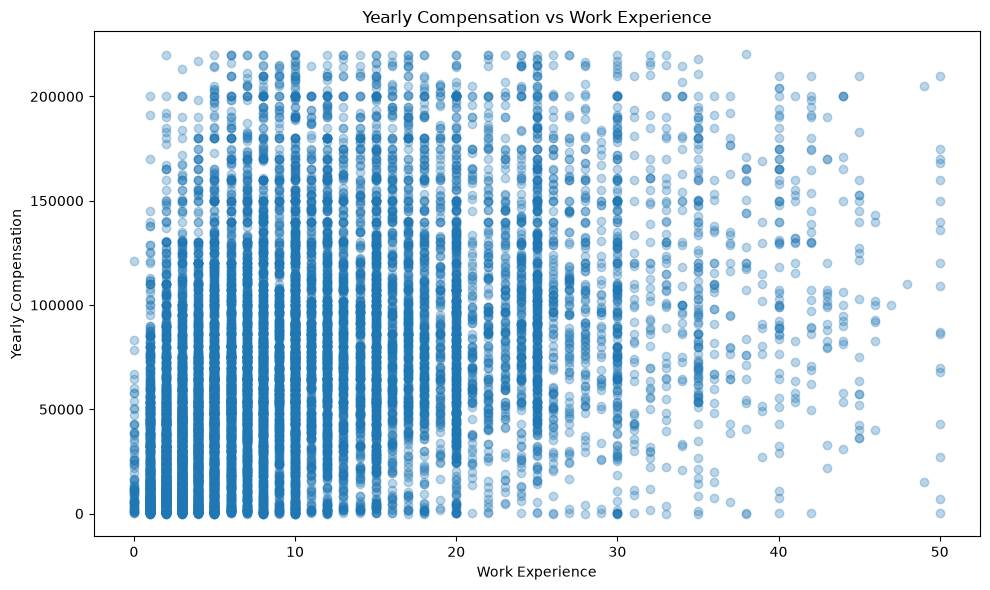

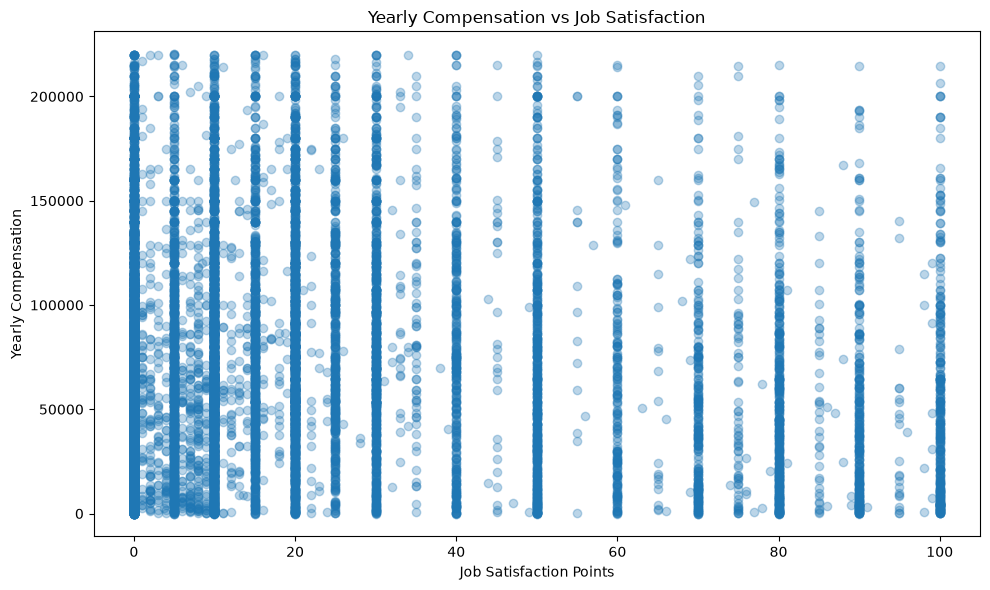

In [8]:
## Write your code here

# Scatter plot: Compensation vs Work Experience
plt.figure(figsize=(10, 6))

plt.scatter(
    correlation_data["WorkExp"],
    correlation_data["ConvertedCompYearly"],
    alpha=0.3
)

plt.title("Yearly Compensation vs Work Experience")
plt.xlabel("Work Experience")
plt.ylabel("Yearly Compensation")
plt.tight_layout()
plt.show()


# Scatter plot: Compensation vs Job Satisfaction
plt.figure(figsize=(10, 6))

plt.scatter(
    correlation_data["JobSatPoints_1"],
    correlation_data["ConvertedCompYearly"],
    alpha=0.3
)

plt.title("Yearly Compensation vs Job Satisfaction")
plt.xlabel("Job Satisfaction Points")
plt.ylabel("Yearly Compensation")
plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
